# BERT Sentiment Analysis for Reddit Comments

This notebook compares BERT-based sentiment analysis with VADER for Reddit comment data from the Sentimentrix project.

## Important Note:
- **VADER** (current Phase II approach): 3-class sentiment (positive/negative/neutral) with compound scores
- **BERT** (this notebook): Deep learning binary classification (positive/negative)

## Goals:
1. Load Reddit comments data
2. Apply BERT sentiment classification
3. Compare BERT results with existing VADER results
4. Analyze accuracy and performance differences

## Step 1: Import Required Libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

device = 0 if torch.cuda.is_available() else -1
print(f"Device: {'GPU' if device == 0 else 'CPU'}")

Device: CPU


## Step 2: Load Data

In [ ]:
import os

# Robust loader: try several relative paths where the CSV might be located
possible_paths = [
    os.path.join('..','..','dataset','reddit_data','WesternU_comments.csv'),
    os.path.join('..','..','data','reddit_data','WesternU_comments.csv'),
    os.path.join('..','data','reddit_data','WesternU_comments.csv'),
    os.path.join('..','..','data','reddit_data','WesternU_comments.csv'),
    os.path.join('..','dataset','reddit_data','WesternU_comments.csv'),
]

comments_path = None
for p in possible_paths:
    if os.path.exists(p):
        comments_path = p
        break

if comments_path is None:
    raise FileNotFoundError(f'Could not find WesternU_comments.csv. Tried: {possible_paths}')

print('Loading comments from:', comments_path)
D_westernu_comments = pd.read_csv(comments_path)
print(f"Total comments: {len(D_westernu_comments)}")
display(D_westernu_comments.head())
print('\nColumns:', D_westernu_comments.columns.tolist())

Total comments: 47


,post_id,comment_id,comment_text,comment_score,comment_author,comment_created_utc,parent_id,reply_to_id,comment_sentiment,has_images,num_images,image_urls,subreddit
0,12p2lmp,kvayuwc,Meee I’m probably doing health sci,1,[deleted],1.710695e+09,t3_12p2lmp,12p2lmp,NaN,False,0,NaN,WesternU
1,12p2lmp,jlprjaz,Hi,1,Purple_Character6184,1.685117e+09,t3_12p2lmp,12p2lmp,NaN,False,0,NaN,WesternU
2,12dvo59,lm2j9yu,"Congrats! May I know your stats, like gpa and ...",1,Only_Researcher6011,1.725773e+09,t3_12dvo59,12dvo59,NaN,False,0,NaN,WesternU
3,ztfu7e,lm9oi3b,I am interested in!,1,Only_Researcher6011,1.725886e+09,t3_ztfu7e,ztfu7e,NaN,False,0,NaN,WesternU
4,ztfu7e,m7hxd3l,yes,1,Eastern-State6466,1.737054e+09,t3_ztfu7e,ztfu7e,NaN,False,0,NaN,WesternU


## Step 3: Data Preprocessing

In [ ]:
# Data preprocessing with gentler filtering
# Minimum comment length to keep (set to 2 to avoid dropping short but valid comments)
MIN_LEN = 2

# Ensure text column exists; try common alternatives if not
text_col = None
for candidate in ['comment_text', 'body', 'text', 'commentBody']:
    if candidate in D_westernu_comments.columns:
        text_col = candidate
        break

if text_col is None:
    raise KeyError(f'No text column found in comments CSV. Columns: {D_westernu_comments.columns.tolist()}')

print('Using text column:', text_col)

# Create cleaned DataFrame
D_comments_clean = D_westernu_comments.dropna(subset=[text_col]).copy()
D_comments_clean[text_col] = D_comments_clean[text_col].astype(str).str.strip()
# Remove empty strings
D_comments_clean = D_comments_clean[D_comments_clean[text_col].str.len() >= MIN_LEN].copy()
# Rename to standard column used downstream
D_comments_clean = D_comments_clean.rename(columns={text_col: 'comment_text'})

print(f"Original rows: {len(D_westernu_comments)}, after dropna and min length ({MIN_LEN}): {len(D_comments_clean)}")
# show sample
display(D_comments_clean[['comment_id', 'comment_text']].head())

Comments after cleaning: 41


## Step 4: Initialize BERT Pipeline

In [ ]:
import platform
# Device selection: prefer CUDA; force CPU on macOS (MPS may be unsupported for some ops)
if torch.cuda.is_available():
    device = 0
    device_name = 'cuda'
else:
    # If on macOS with MPS available, still prefer CPU to avoid unimplemented ops
    try:
        mps_available = getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available()
    except Exception:
        mps_available = False
    if platform.system() == 'Darwin' and mps_available:
        print('macOS with MPS detected — forcing CPU for compatibility')
        device = -1
        device_name = 'cpu'
    else:
        device = -1
        device_name = 'cpu'

print(f"Device: {device_name} (pipeline device={device})")

print("Loading BERT model (this may take a moment)...")
bert_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=device,
    truncation=True,
)
print("✓ BERT pipeline ready")

Loading BERT...
✓ BERT loaded!


## Step 5: Apply BERT Analysis

In [ ]:
# Apply BERT in batches, handle long texts, and save results
from tqdm.notebook import tqdm

BATCH_SIZE = 16
MAX_LENGTH = 512

texts = D_comments_clean['comment_text'].astype(str).tolist()
all_labels = []
all_scores = []

print(f'Processing {len(texts)} comments in batches of {BATCH_SIZE}...')
for i in tqdm(range(0, len(texts), BATCH_SIZE)):
    batch = [t[:MAX_LENGTH] for t in texts[i:i+BATCH_SIZE]]
    try:
        outputs = bert_pipeline(batch)
    except Exception as e:
        # fallback: process one-by-one
        outputs = []
        for t in batch:
            try:
                outputs.append(bert_pipeline(t)[0])
            except Exception:
                outputs.append({'label': 'NEGATIVE', 'score': 0.0})
    for out in outputs:
        lbl = 'positive' if out.get('label', '').upper().startswith('POS') else 'negative'
        sc = float(out.get('score', 0.0))
        all_labels.append(lbl)
        all_scores.append(sc)

# Attach results; ensure lengths match
if len(all_labels) != len(D_comments_clean):
    # align by truncating or padding
    n = len(D_comments_clean)
    all_labels = (all_labels + ['unknown'] * n)[:n]
    all_scores = (all_scores + [0.0] * n)[:n]

D_comments_clean['bert_sentiment'] = all_labels
D_comments_clean['bert_confidence'] = all_scores

print('✓ BERT classification complete')
print(D_comments_clean['bert_sentiment'].value_counts())

# Ensure VADER sentiment labels are present: try to load export; if missing, compute quickly here
vader_paths = [
    os.path.join('..','..','dataset','reddit_data','WesternU_comments_vader_sentiment.csv'),
    os.path.join('..','..','data','reddit_data','WesternU_comments_vader_sentiment.csv'),
    os.path.join('..','data','reddit_data','WesternU_comments_vader_sentiment.csv')
]

vader_file = None
for p in vader_paths:
    if os.path.exists(p):
        vader_file = p
        break

if vader_file:
    print('Loading VADER labels from', vader_file)
    vader_df = pd.read_csv(vader_file)
    # merge on comment_id if available
    if 'comment_id' in D_comments_clean.columns and 'comment_id' in vader_df.columns:
        D_comments_clean = D_comments_clean.merge(vader_df, on='comment_id', how='left')
    else:
        # if no ids, try aligning by index
        D_comments_clean['comment_sentiment'] = vader_df['comment_sentiment'].values[:len(D_comments_clean)]
else:
    print('No exported VADER file found — computing VADER labels in-notebook (this may take a moment)')
    import nltk
    nltk.download('vader_lexicon', quiet=True)
    from nltk.sentiment.vader import SentimentIntensityAnalyzer
    analyzer = SentimentIntensityAnalyzer()
    D_comments_clean['sentiment_scores_temp'] = D_comments_clean['comment_text'].apply(lambda x: analyzer.polarity_scores(x) if isinstance(x, str) else {'compound': 0.0})
    D_comments_clean['compound_temp'] = D_comments_clean['sentiment_scores_temp'].apply(lambda x: x['compound'])
    def get_sentiment_label(comp):
        if comp >= 0.05: return 'positive'
        if comp <= -0.05: return 'negative'
        return 'neutral'
    D_comments_clean['comment_sentiment'] = D_comments_clean['compound_temp'].apply(get_sentiment_label)
    # cleanup temp cols
    D_comments_clean.drop(columns=['sentiment_scores_temp','compound_temp'], inplace=True)

# Save a copy of results for later use
out_path = os.path.join('..','..','dataset','reddit_data','WesternU_comments_bert_results.csv')
D_comments_clean.to_csv(out_path, index=False)
print('Saved BERT results to', out_path)

# Quick comparison print
print('\nVADER counts:')
if 'comment_sentiment' in D_comments_clean.columns:
    print(D_comments_clean['comment_sentiment'].value_counts())
print('\nBERT counts:')
print(D_comments_clean['bert_sentiment'].value_counts())

Processing 41 comments...
✓ Complete!


## Step 6: Results

In [13]:
print("BERT Sentiment Distribution:")
print(D_comments_clean['bert_sentiment'].value_counts())
print(f"\nAverage Confidence: {D_comments_clean['bert_confidence'].mean():.4f}")

BERT Sentiment Distribution:
bert_sentiment
negative    25
positive    16
Name: count, dtype: int64

Average Confidence: 0.9595


## Step 7: Visualization

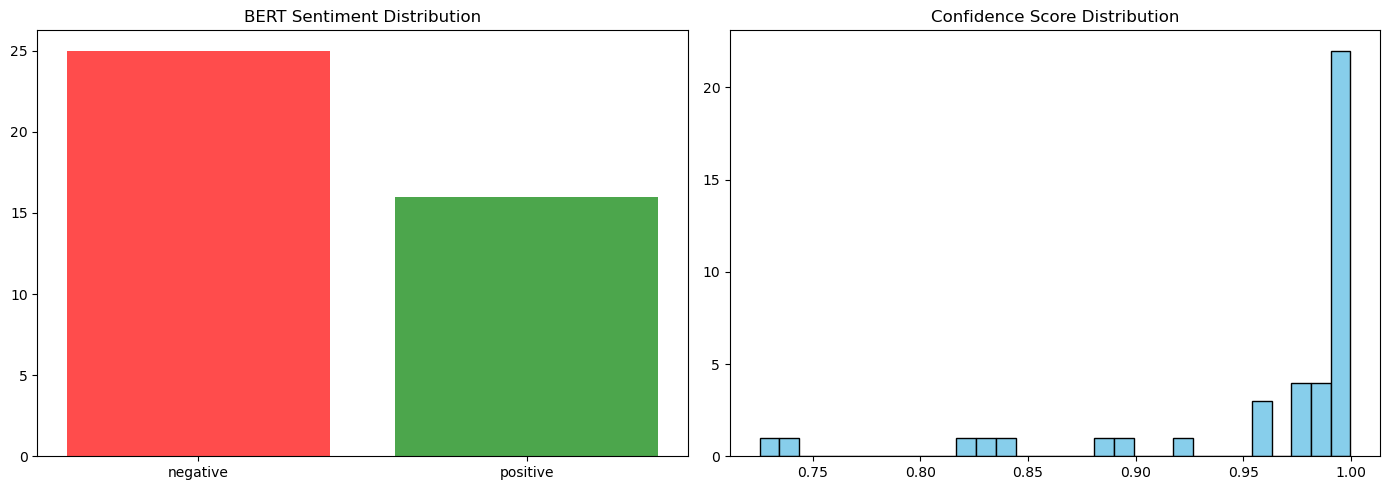

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sentiment_counts = D_comments_clean['bert_sentiment'].value_counts()
colors = ['green' if x == 'positive' else 'red' for x in sentiment_counts.index]
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors, alpha=0.7)
axes[0].set_title('BERT Sentiment Distribution')

axes[1].hist(D_comments_clean['bert_confidence'], bins=30, color='skyblue', edgecolor='black')
axes[1].set_title('Confidence Score Distribution')

plt.tight_layout()
plt.show()